## Gender Classification Model

### Problem Statement
The objective of this task is to build a classification model to predict the gender of users based on available demographic features such as age and company.

### Business Use Case
Understanding user demographics helps travel platforms personalize recommendations, improve marketing strategies, and enhance user engagement.

### Dataset Description
The Users dataset contains:
- userCode: Unique user ID
- company: Associated company
- age: Age of user
- gender: Target variable

### GitHub Repository
[Voyage-Analytics-MLops](https://github.com/Aks18had/Voyage-Analytics-MLops)

In [ ]:
from google.colab import drive #Mounting the Drive first
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os #Giving the path

base_path = '/content/drive/MyDrive/Voyage-Analytics-MLops'
data_path = os.path.join(base_path, 'data')

print(os.listdir(data_path))

['flights.csv', 'users.csv', 'hotels.csv']


In [ ]:
import pandas as pd # Loading the dataset

users = pd.read_csv(os.path.join(data_path, 'users.csv'))

users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [ ]:
users.info() #Understanding the data of users or we said here as Gender classification
users['gender'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


,count
gender,
male,452
female,448
none,440


### Observations

- Dataset contains demographic information of users.
- Gender is the target variable for classification.
- Features like age and company may influence prediction.

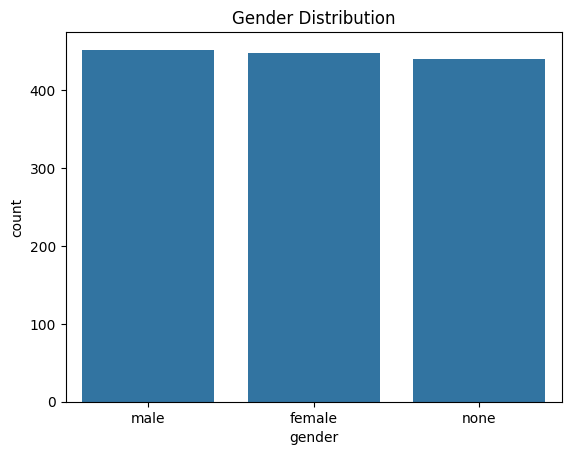

In [ ]:
import seaborn as sns # Importing Seaborn to show the gender distribution
import matplotlib.pyplot as plt

sns.countplot(x='gender', data=users)
plt.title("Gender Distribution")
plt.show()

### Gender Distribution

The dataset shows the distribution of male and female users.

This helps identify class balance, which is important for classification model performance.

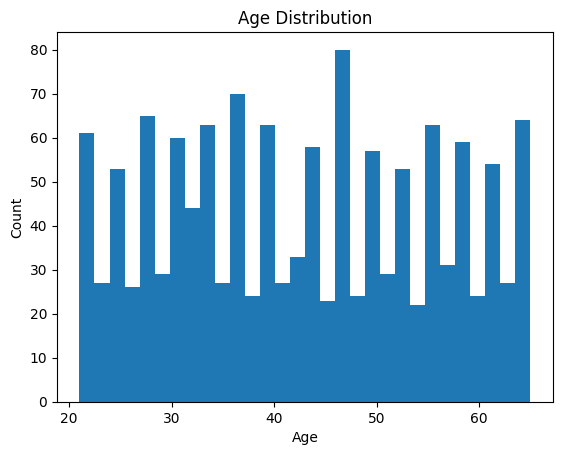

In [ ]:
plt.hist(users['age'], bins=30) #Age distribution using Histogram
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution

The age distribution provides insight into the demographic spread of users.

This feature may influence gender classification.

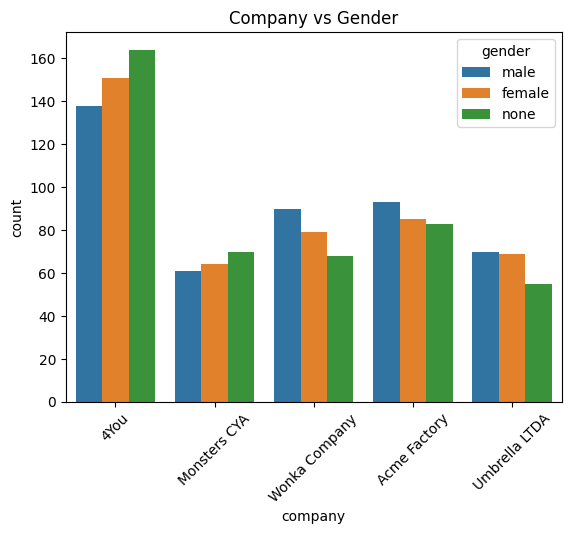

In [ ]:
sns.countplot(x='company', hue='gender', data=users) # Gender vs Company chart
plt.xticks(rotation=45)
plt.title("Company vs Gender")
plt.show()

### Company vs Gender

Different companies show varying gender distributions, which can be useful for classification.

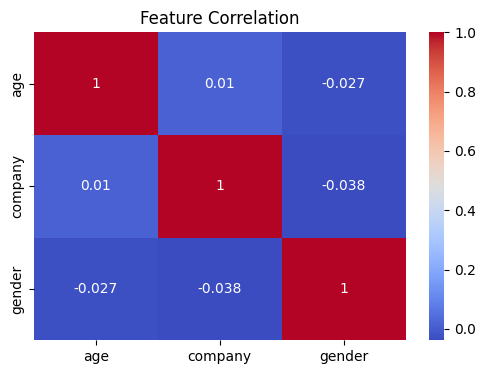

In [ ]:
plt.figure(figsize=(6,4)) # Coorelation map
sns.heatmap(users_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Correlation Analysis

The correlation heatmap shows relationships between encoded features and the target variable.

This helps understand feature importance.

In [ ]:
users_clean = users.copy() #Data cleaning

users_clean = users_clean[['age', 'company', 'gender']]

users_clean.dropna(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder # Label Encoding

le_company = LabelEncoder()
users_clean['company'] = le_company.fit_transform(users_clean['company'])

le_gender = LabelEncoder()
users_clean['gender'] = le_gender.fit_transform(users_clean['gender'])

In [ ]:
X = users_clean.drop('gender', axis=1)
y = users_clean['gender']

In [ ]:
from sklearn.model_selection import train_test_split # Basci train and test split of 80:20 ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier #Model Building importing the Random forest
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.2947761194029851
              precision    recall  f1-score   support

           0       0.30      0.33      0.31        89
           1       0.30      0.26      0.28        94
           2       0.28      0.31      0.29        85

    accuracy                           0.29       268
   macro avg       0.30      0.30      0.29       268
weighted avg       0.30      0.29      0.29       268



### Model Performance

The Random Forest classifier was used due to its ability to handle non-linear relationships.

Accuracy and classification metrics indicate the effectiveness of the model.

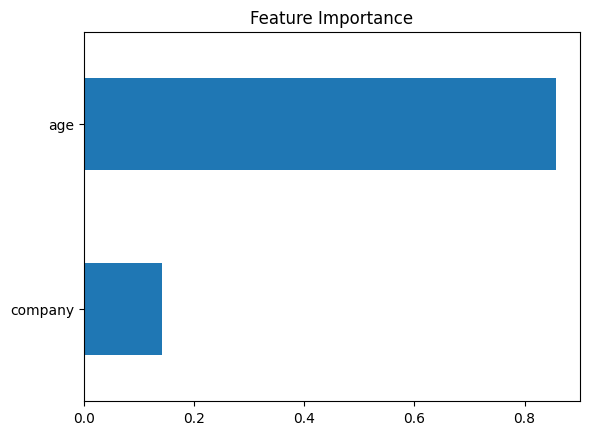

In [ ]:
import pandas as pd

feature_importance = pd.Series(clf.feature_importances_, index=X.columns)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

### Feature Importance

The model identifies which features contribute most to gender prediction.

In [ ]:
import joblib # Saving the Modelfrom using Joblib as this will do all in 3 notebooks

model_path = os.path.join(base_path, 'models/gender_model.pkl')
joblib.dump(clf, model_path)

['/content/drive/MyDrive/Voyage-Analytics-MLops/models/gender_model.pkl']

### Conclusion

A gender classification model was successfully developed using user demographic data.

This model demonstrates classification capabilities within the overall ML system and can be integrated into recommendation systems for personalization.